# Medusa Analysis

## Medusa Mean Tokens accepted analysis

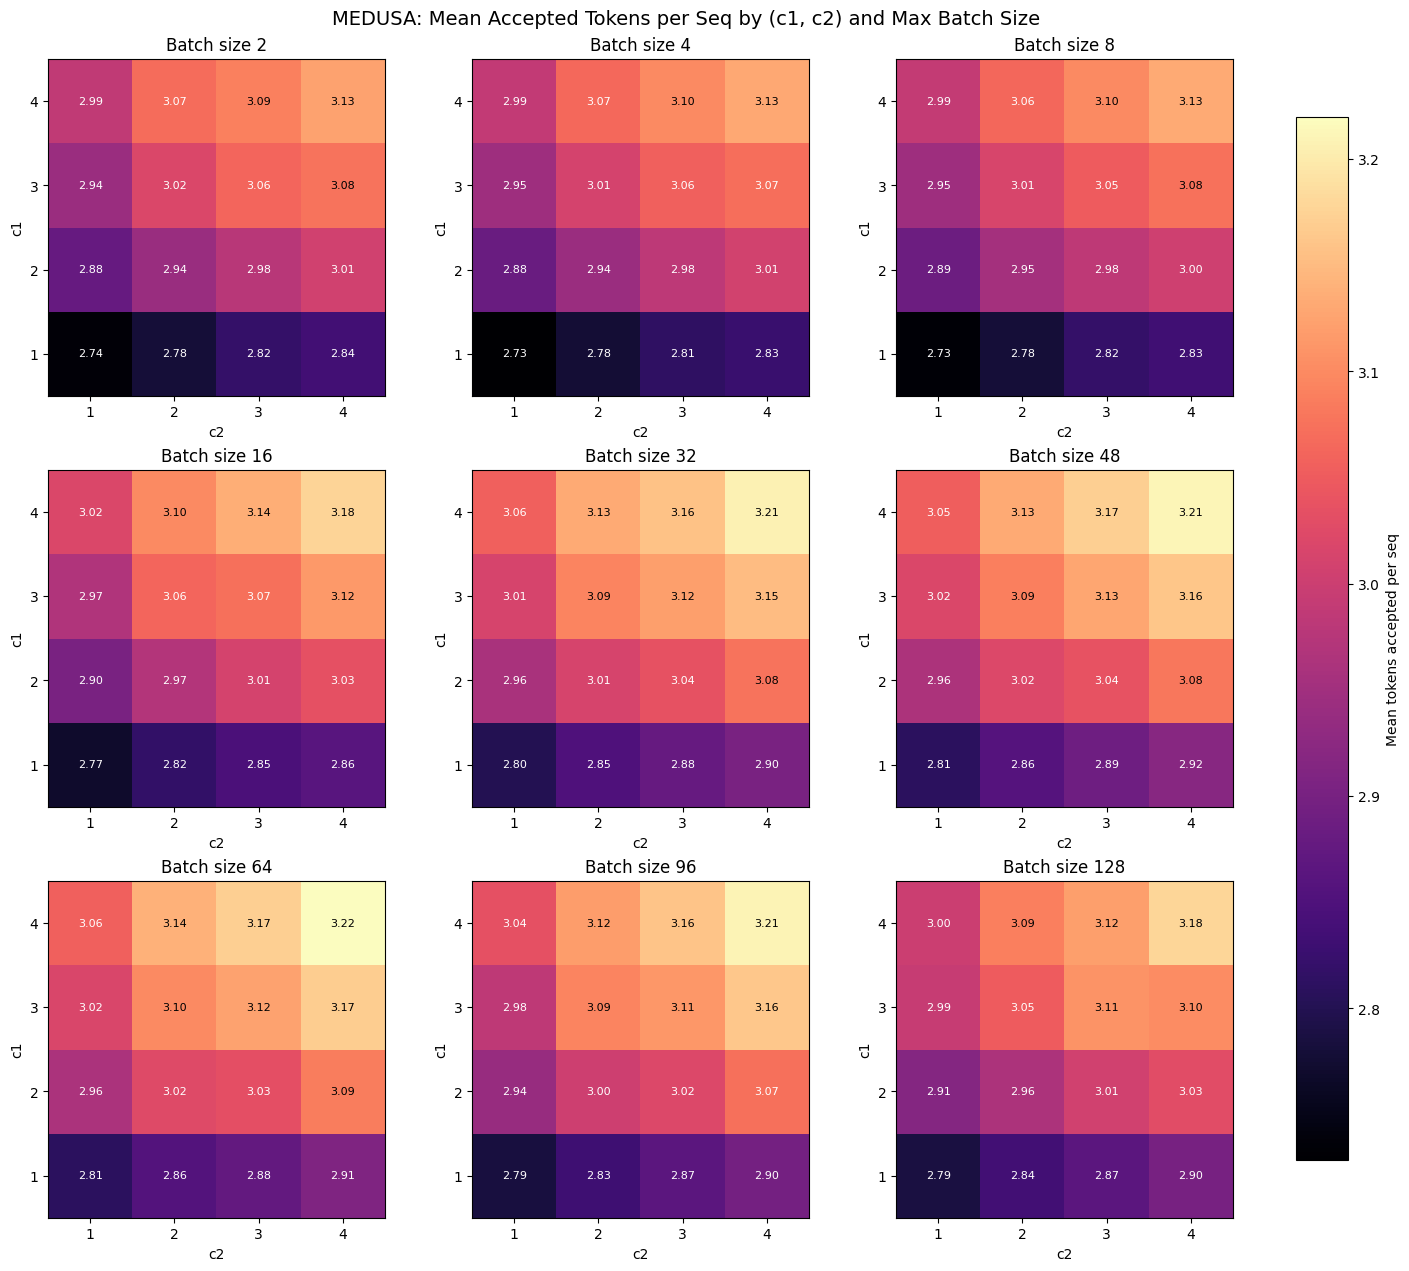

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR_CANDIDATES = [Path('bench_csvs/medusa'), Path('modal_throughput_ablations/bench_csvs/medusa')]
DATA_DIR = next((d for d in DATA_DIR_CANDIDATES if d.is_dir()), DATA_DIR_CANDIDATES[0])
PATTERN = re.compile(r'^medusa_bs(?P<bs>\d+)_c1_(?P<c1>\d+)_c2_(?P<c2>\d+)_n128(?:-\d{8}-\d{6}-[0-9a-f]+)?\.data\.csv$')
TARGET_COL = 'mean_tokens_accepted_per_seq'

records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128*.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if TARGET_COL not in df.columns:
        continue

    # Ignore sentinel values from non-decode steps.
    vals = pd.to_numeric(df[TARGET_COL], errors='coerce')
    vals = vals[vals >= 0]
    mean_val = float(vals.mean()) if len(vals) else np.nan

    records.append({'bs': bs, 'c1': c1, 'c2': c2, 'mean_tokens_accepted_per_seq': mean_val})

agg = pd.DataFrame(records)
if agg.empty:
    raise RuntimeError(f'No MEDUSA CSVs with the target column were found in {DATA_DIR}.')

batch_sizes = sorted(agg['bs'].unique())
n = len(batch_sizes)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.2 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

vmin = agg['mean_tokens_accepted_per_seq'].min()
vmax = agg['mean_tokens_accepted_per_seq'].max()

im = None
for i, bs in enumerate(batch_sizes):
    ax = axes[i]
    sub = agg[agg['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values='mean_tokens_accepted_per_seq').reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im = ax.imshow(mat.values, origin='lower', cmap='magma', vmin=vmin, vmax=vmax, aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im.cmap(im.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

if im is not None:
    cbar = fig.colorbar(im, ax=axes[:n], shrink=0.9)
    cbar.set_label('Mean tokens accepted per seq')

fig.suptitle('MEDUSA: Mean Accepted Tokens per Seq by (c1, c2) and Max Batch Size', fontsize=14)
plt.show()

#agg.sort_values(['bs', 'c1', 'c2']).head()

## Medusa throughput analysis

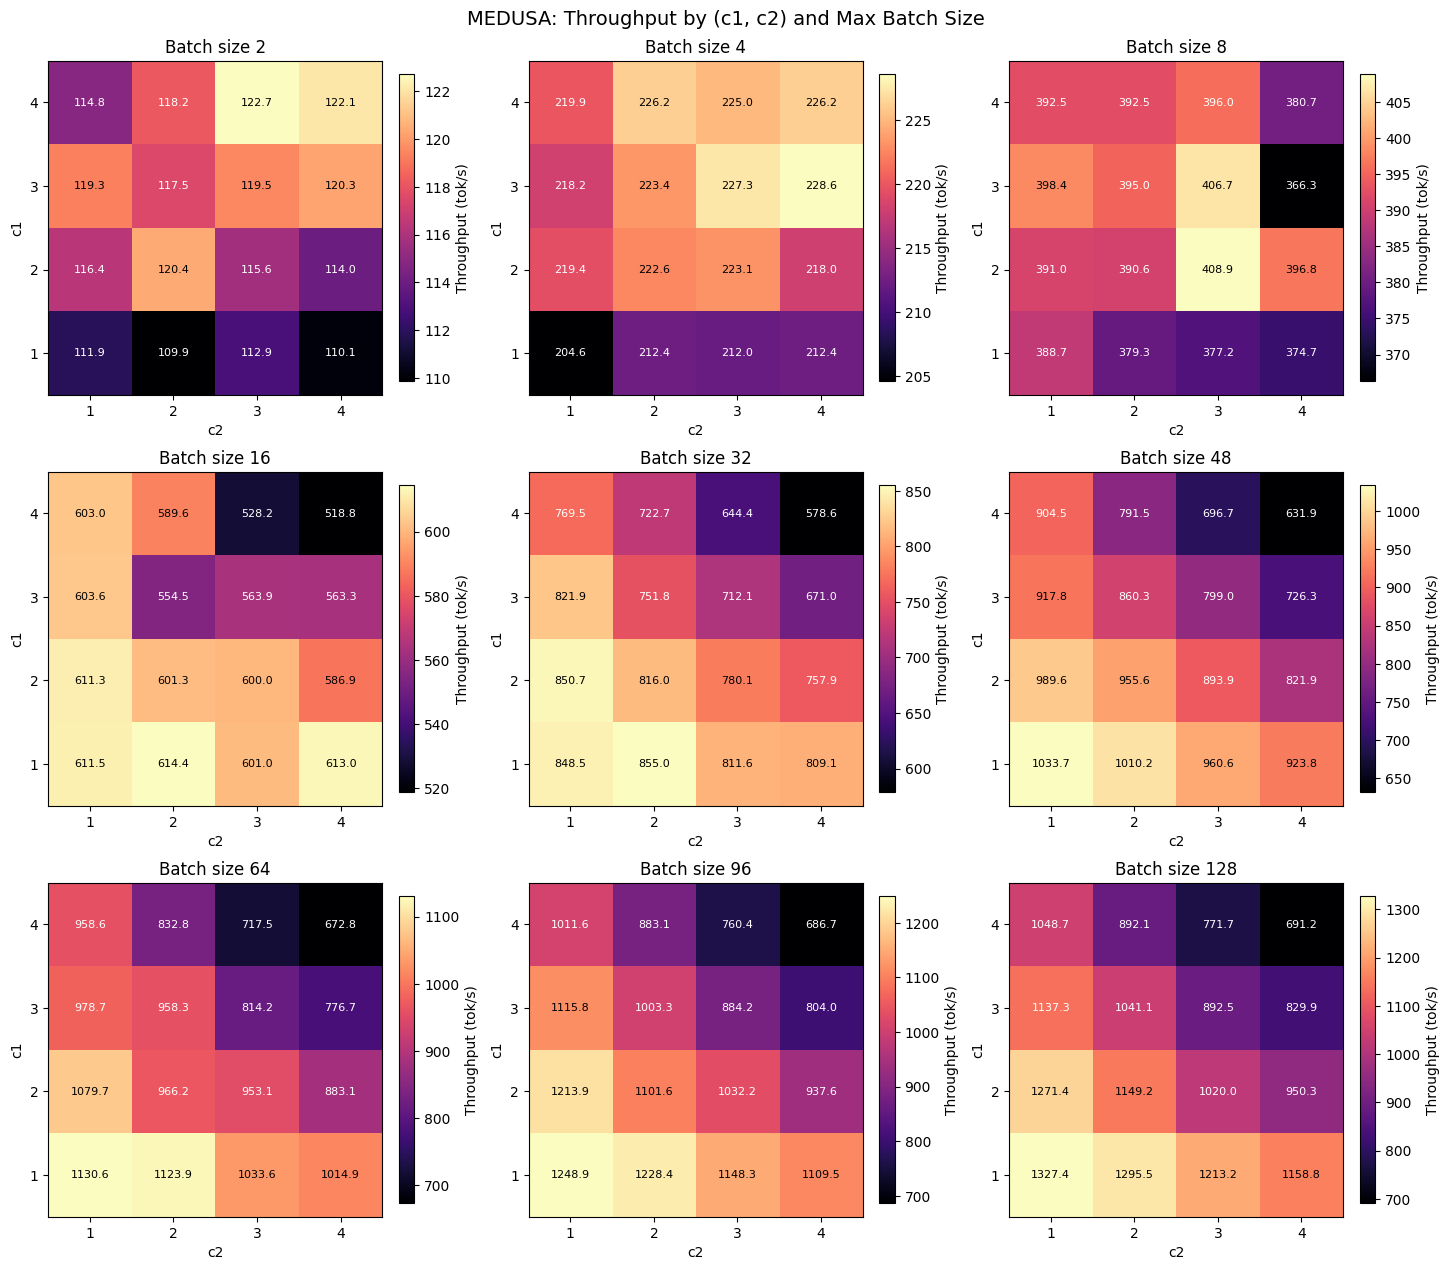

In [2]:
# Throughput heatmaps by batch size (computed from timestamps and total tokens)

THROUGHPUT_COL = 'throughput_tok_s'

t_records = []
for csv_path in sorted(DATA_DIR.glob('medusa_bs*_c1_*_c2_*_n128-*.data.csv')):
    m = PATTERN.match(csv_path.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    df = pd.read_csv(csv_path)
    if 'total_generated_tokens' not in df.columns or 'timestamp' not in df.columns or df.empty:
        continue

    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        continue

    t0 = float(ts.iloc[0])
    t1 = float(ts.iloc[-1])
    total = float(tg.iloc[-1])

    elapsed = t1 - t0
    throughput = (total / elapsed) if elapsed > 0 else np.nan

    t_records.append({'bs': bs, 'c1': c1, 'c2': c2, THROUGHPUT_COL: throughput})

thr = pd.DataFrame(t_records)
if thr.empty:
    raise RuntimeError('No MEDUSA CSVs with timestamp/total_generated_tokens were found.')

batch_sizes_t = sorted(thr['bs'].unique())
n_t = len(batch_sizes_t)
ncols_t = 3
nrows_t = (n_t + ncols_t - 1) // ncols_t

fig, axes = plt.subplots(nrows_t, ncols_t, figsize=(4.8 * ncols_t, 4.2 * nrows_t), constrained_layout=True)
axes = np.array(axes).reshape(-1)

im_t = None
for i, bs in enumerate(batch_sizes_t):
    ax = axes[i]
    sub = thr[thr['bs'] == bs]
    mat = sub.pivot(index='c1', columns='c2', values=THROUGHPUT_COL).reindex(index=[1,2,3,4], columns=[1,2,3,4])

    im_t = ax.imshow(mat.values, origin='lower', cmap='magma', aspect='equal')
    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(4))
    ax.set_xticklabels([1,2,3,4])
    ax.set_yticks(range(4))
    ax.set_yticklabels([1,2,3,4])

    for r in range(4):
        for c in range(4):
            val = mat.values[r, c]
            if np.isfinite(val):
                rgba = im_t.cmap(im_t.norm(val))
                luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if luminance > 0.55 else 'white'
                ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

for i, bs in enumerate(batch_sizes_t):
    if i < len(axes) and axes[i].images:
        cbar = fig.colorbar(axes[i].images[0], ax=axes[i], shrink=0.9)
        cbar.set_label('Throughput (tok/s)')

fig.suptitle('MEDUSA: Throughput by (c1, c2) and Max Batch Size', fontsize=14)
plt.show()

#thr.sort_values(['bs', 'c1', 'c2']).head()


## MEDUSA Best-Config Speedup vs Baseline
For each batch size, select the `(c1, c2)` MEDUSA configuration with the highest throughput, then compare that best MEDUSA throughput to the no-spec baseline throughput.

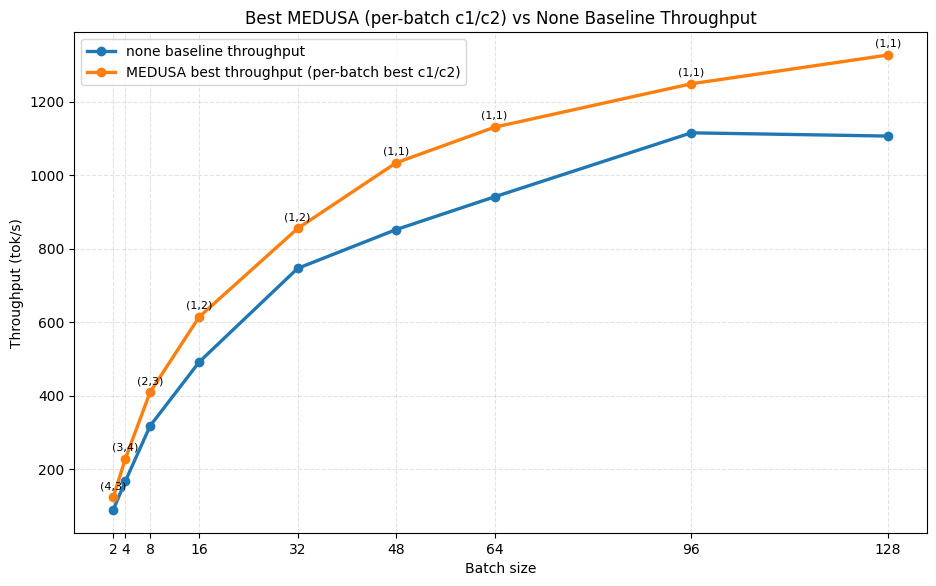

In [3]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MEDUSA_DIR = Path('bench_csvs/medusa')
NONE_DIR = Path('bench_csvs/none')

pat_medusa = re.compile(r'^medusa_bs(?P<bs>\d+)_c1_(?P<c1>\d+)_c2_(?P<c2>\d+)_n128(?:-\d{8}-\d{6}-[0-9a-f]+)?\.data\.csv$')
pat_none = re.compile(r'^none-bs_(?P<bs>\d+)-n128(?:-\d{8}-\d{6}-[0-9a-f]+)?\.data\.csv$')


def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty or 'timestamp' not in df.columns or 'total_generated_tokens' not in df.columns:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

# --- Baseline none throughput per batch size ---
none_rows = []
for p in sorted(NONE_DIR.glob('none-bs_*-n128*.data.csv')):
    m = pat_none.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    none_rows.append({'bs': bs, 'baseline_tput': throughput_from_csv(p), 'none_file': p.name})

none_df = pd.DataFrame(none_rows)
if none_df.empty:
    raise RuntimeError('No baseline none CSVs found.')

none_df = none_df.sort_values(['bs', 'none_file']).drop_duplicates(subset=['bs'], keep='last')

# --- MEDUSA throughput per (bs, c1, c2) ---
medusa_rows = []
for p in sorted(MEDUSA_DIR.glob('medusa_bs*_c1_*_c2_*_n128*.data.csv')):
    m = pat_medusa.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))
    medusa_rows.append({
        'bs': bs,
        'c1': c1,
        'c2': c2,
        'medusa_tput': throughput_from_csv(p),
        'medusa_file': p.name,
    })

medusa_df = pd.DataFrame(medusa_rows)
if medusa_df.empty:
    raise RuntimeError('No MEDUSA CSVs found.')

# Pick best (c1,c2) for each batch size by throughput.
idx = medusa_df.groupby('bs')['medusa_tput'].idxmax()
best_medusa = medusa_df.loc[idx].sort_values('bs').reset_index(drop=True)

plot_df = best_medusa.merge(none_df[['bs', 'baseline_tput']], on='bs', how='inner')
plot_df['speedup_vs_baseline'] = plot_df['medusa_tput'] / plot_df['baseline_tput']

if plot_df.empty:
    raise RuntimeError('Could not join MEDUSA best configs with baseline by batch size.')

# --- Plot 1: throughput curves (best MEDUSA vs baseline) ---
fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(plot_df['bs'], plot_df['baseline_tput'], marker='o', linewidth=2.4, label='none baseline throughput')
ax.plot(plot_df['bs'], plot_df['medusa_tput'], marker='o', linewidth=2.4, label='MEDUSA best throughput (per-batch best c1/c2)')

for _, r in plot_df.iterrows():
    ax.annotate(f"({int(r['c1'])},{int(r['c2'])})", (r['bs'], r['medusa_tput']), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)

ax.set_xticks(sorted(plot_df['bs'].unique()))
ax.set_xlabel('Batch size')
ax.set_ylabel('Throughput (tok/s)')
ax.set_title('Best MEDUSA (per-batch c1/c2) vs None Baseline Throughput')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend()
plt.show()

# SpecDec analysis

## Naive SpecDec throughput analysis

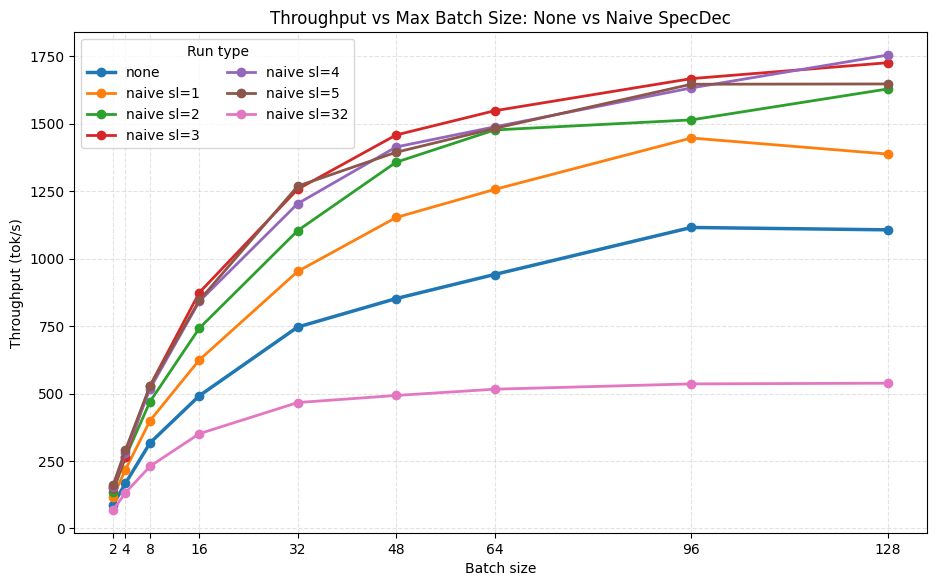

In [4]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NONE_DIR = Path('bench_csvs/none')
NAIVE_DIR = Path('bench_csvs/naive')

pat_none = re.compile(r'^none-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')
pat_naive = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.data\.csv$')

def throughput_from_csv(path: Path) -> float:
    df = pd.read_csv(path)
    if df.empty:
        return np.nan
    ts = pd.to_numeric(df['timestamp'], errors='coerce')
    tg = pd.to_numeric(df['total_generated_tokens'], errors='coerce')
    if ts.isna().all() or tg.isna().all():
        return np.nan
    elapsed = float(ts.iloc[-1]) - float(ts.iloc[0])
    total = float(tg.iloc[-1])
    return total / elapsed if elapsed > 0 else np.nan

rows = []

for p in sorted(NONE_DIR.glob('none-bs_*-n128-*.data.csv')):
    m = pat_none.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'none', 'spec_len': 0, 'bs': bs, 'throughput': thr, 'file': p.name})

for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.data.csv')):
    m = pat_naive.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    sl = int(m.group('sl'))
    thr = throughput_from_csv(p)
    rows.append({'method': 'naive', 'spec_len': sl, 'bs': bs, 'throughput': thr, 'file': p.name})

plot_df = pd.DataFrame(rows)
if plot_df.empty:
    raise RuntimeError('No none/naive benchmark CSVs found.')

plot_df = plot_df.sort_values(['method', 'spec_len', 'bs'])

fig, ax = plt.subplots(figsize=(11, 6.5))

none_df = plot_df[plot_df['method'] == 'none'].sort_values('bs')
ax.plot(
    none_df['bs'],
    none_df['throughput'],
    marker='o',
    linewidth=2.5,
    label='none',
)

for sl in sorted(plot_df.loc[plot_df['method'] == 'naive', 'spec_len'].unique()):
    sub = plot_df[(plot_df['method'] == 'naive') & (plot_df['spec_len'] == sl)].sort_values('bs')
    ax.plot(
        sub['bs'],
        sub['throughput'],
        marker='o',
        linewidth=2,
        label=f'naive sl={sl}',
    )

ax.set_xticks(sorted(plot_df['bs'].unique()))
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel('Batch size')
ax.set_ylabel('Throughput (tok/s)')
ax.set_title('Throughput vs Max Batch Size: None vs Naive SpecDec')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(title='Run type', ncol=2)
plt.show()

#plot_df[['method', 'spec_len', 'bs', 'throughput']].sort_values(['method', 'spec_len', 'bs'])


## Naive Specdec Rejection PMF / CDF Analysis

Using the speclen=32 traces, we generate a PDF and CDF of the rejection probabilities for each step, and report p50, p90, and p99 values for the CDF.
This proves that any speculation method that does not incorporate feedback from the target model will have diminishing returns as the speclen increases, since the rejection probability grows significantly with the speclen.

We empirically prove with the p50, p90, and p95 values that the majority of speculation benefit comes in the first few speculated tokens.

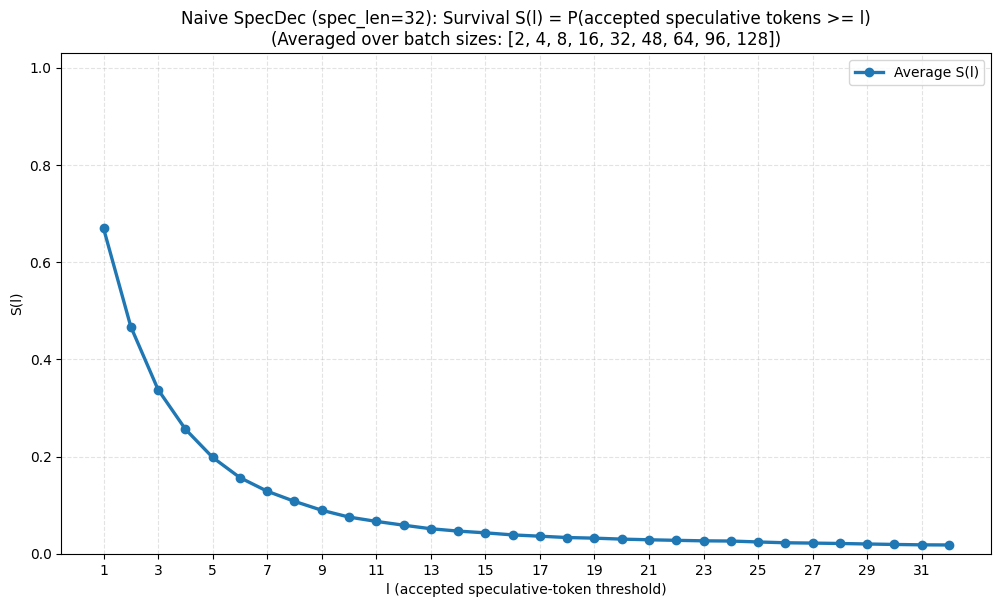

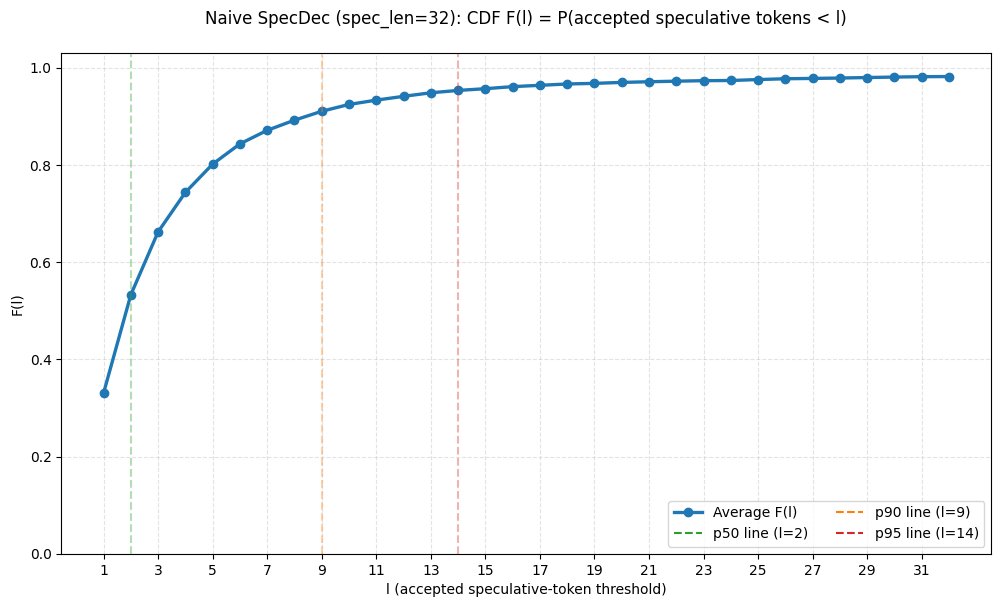

In [5]:
import json
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

NAIVE_DIR = Path('bench_csvs/naive')
PAT = re.compile(r'^naive-speclen_32-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.decode_len_hist\.json$')
SPEC_LEN = 32


def _extract_hist(path: Path) -> tuple[int, dict[int, int]]:
    with open(path, 'r', encoding='utf-8') as f:
        payload = json.load(f)
    acc = payload.get('accepted_spec_tokens', {})
    hist_raw = acc.get('hist', {})
    hist = {int(k): int(v) for k, v in hist_raw.items() if int(v) > 0}
    n = int(acc.get('num_samples', sum(hist.values())))
    if n <= 0:
        n = sum(hist.values())
    return n, hist


def _first_l_for_cdf(values_l: np.ndarray, cdf: np.ndarray, q: float) -> int:
    idx = int(np.searchsorted(cdf, q, side='left'))
    idx = min(max(idx, 0), len(values_l) - 1)
    return int(values_l[idx])


runs = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_32-bs_*-n128-*.decode_len_hist.json')):
    m = PAT.match(p.name)
    if not m:
        continue
    bs = int(m.group('bs'))
    n, hist = _extract_hist(p)
    if not hist or n <= 0:
        continue
    runs.append((bs, p.name, n, hist))

if not runs:
    raise RuntimeError('No speclen=32 naive histogram JSONs found with accepted_spec_tokens.')

runs = sorted(runs, key=lambda x: x[0])
ls = np.arange(1, SPEC_LEN + 1, dtype=int)

# Build per-batch survival curves S(l)=P(accepted>=l), then average over batch sizes.
surv_curves = []
for _, _, n, hist in runs:
    surv = np.array([
        sum(hist.get(int(k), 0) for k in range(int(l), SPEC_LEN + 1)) / n
        for l in ls
    ], dtype=float)
    surv_curves.append(surv)

surv_curves = np.array(surv_curves)
surv_avg = np.nanmean(surv_curves, axis=0)
cdf_avg = 1.0 - surv_avg

# Quantiles from averaged CDF.
l50 = _first_l_for_cdf(ls, cdf_avg, 0.50)
l90 = _first_l_for_cdf(ls, cdf_avg, 0.90)
l95 = _first_l_for_cdf(ls, cdf_avg, 0.95)

batch_sizes = [bs for bs, _, _, _ in runs]
label_suffix = f'(Averaged over batch sizes: {batch_sizes})'

# ---- Averaged Survival ----
fig_s, ax_s = plt.subplots(figsize=(12, 6.5))
ax_s.plot(ls, surv_avg, marker='o', linewidth=2.4, color='tab:blue', label='Average S(l)')
ax_s.set_title('Naive SpecDec (spec_len=32): Survival S(l) = P(accepted speculative tokens >= l)\n' + label_suffix)
ax_s.set_xlabel('l (accepted speculative-token threshold)')
ax_s.set_ylabel('S(l)')
ax_s.set_ylim(0.0, 1.03)
ax_s.set_xticks(np.arange(1, SPEC_LEN + 1, 2))
ax_s.grid(True, linestyle='--', alpha=0.35)
ax_s.legend()
plt.show()

# ---- Averaged CDF with quantile lines ----
fig_cdf, ax_cdf = plt.subplots(figsize=(12, 6.5))
ax_cdf.plot(ls, cdf_avg, marker='o', linewidth=2.4, color='tab:blue', label='Average F(l)')

for lv, color in [
    (l50, 'tab:green'),
    (l90, 'tab:orange'),
    (l95, 'tab:red'),
]:
    ax_cdf.axvline(lv, linestyle='--', linewidth=1.5, color=color, alpha=0.35)

quantile_handles = [
    Line2D([0], [0], color='tab:green', linestyle='--', linewidth=1.5, label=f'p50 line (l={l50})'),
    Line2D([0], [0], color='tab:orange', linestyle='--', linewidth=1.5, label=f'p90 line (l={l90})'),
    Line2D([0], [0], color='tab:red', linestyle='--', linewidth=1.5, label=f'p95 line (l={l95})'),
]
curve_handles, curve_labels = ax_cdf.get_legend_handles_labels()
ax_cdf.legend(handles=curve_handles + quantile_handles, ncol=2)

ax_cdf.set_title('Naive SpecDec (spec_len=32): CDF F(l) = P(accepted speculative tokens < l)\n')
ax_cdf.set_xlabel('l (accepted speculative-token threshold)')
ax_cdf.set_ylabel('F(l)')
ax_cdf.set_ylim(0.0, 1.03)
ax_cdf.set_xticks(np.arange(1, SPEC_LEN + 1, 2))
ax_cdf.grid(True, linestyle='--', alpha=0.35)
plt.show()


# Naive Accepted-Spec Tokens Analysis (Mean Tokens Analysis as well as Median Sequence Survival Analysis)
Compute per-run accepted-spec-token histograms from JSON sidecars, build survival/CDF, then heatmap the CDF median threshold (`p50`) and the histogram mean.

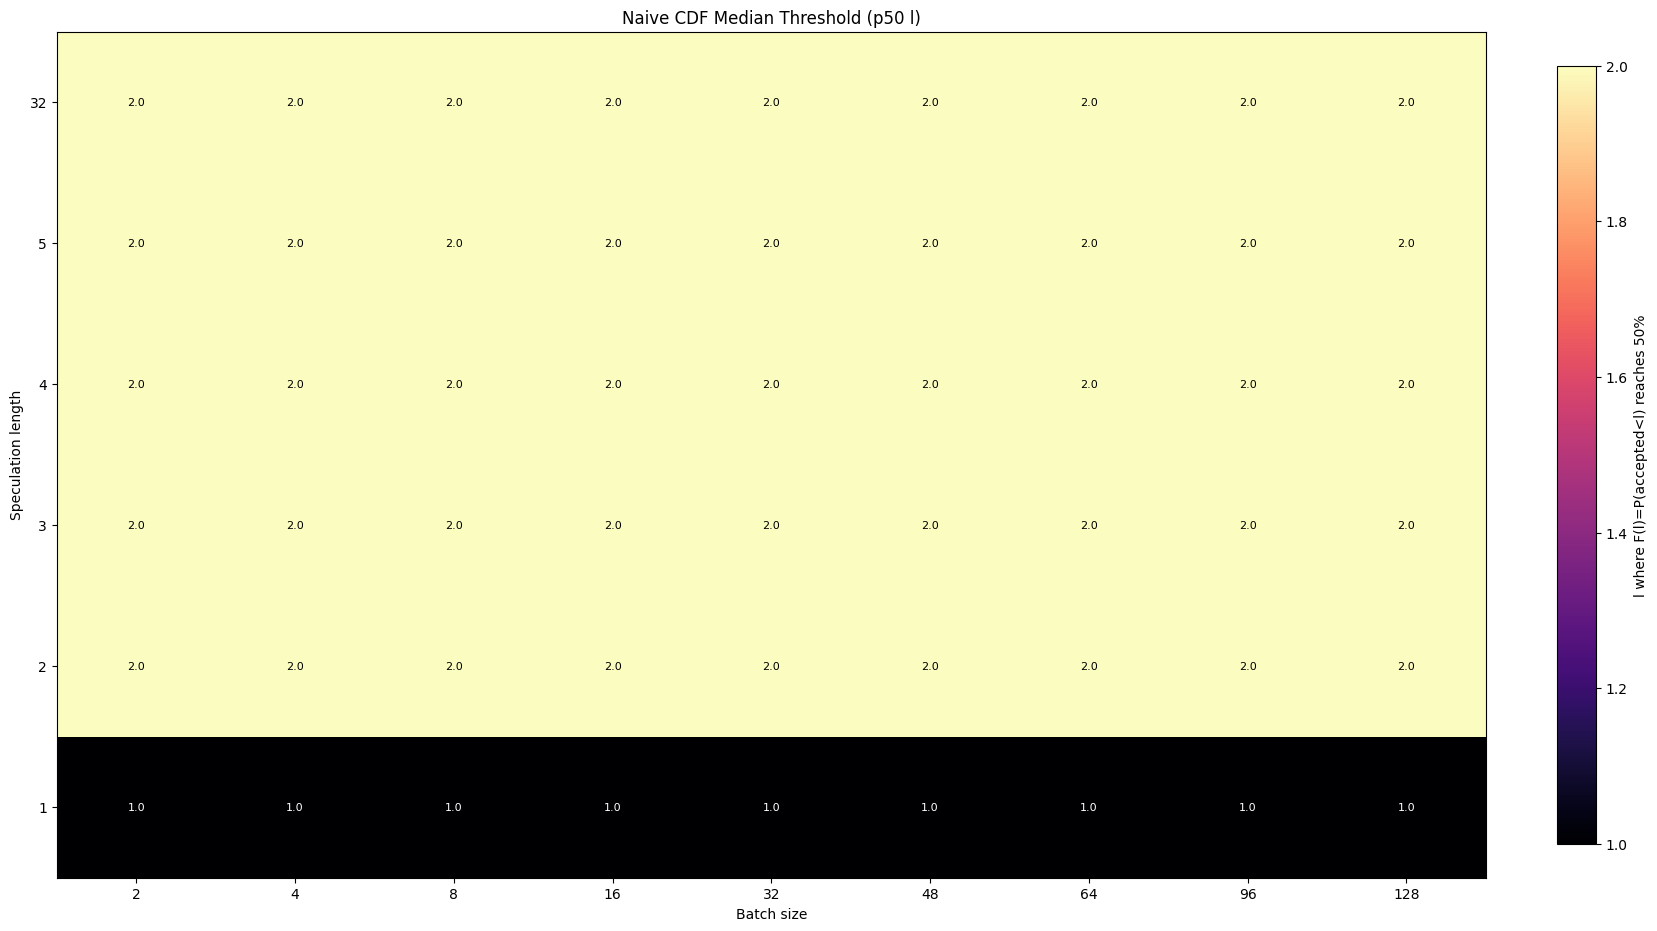

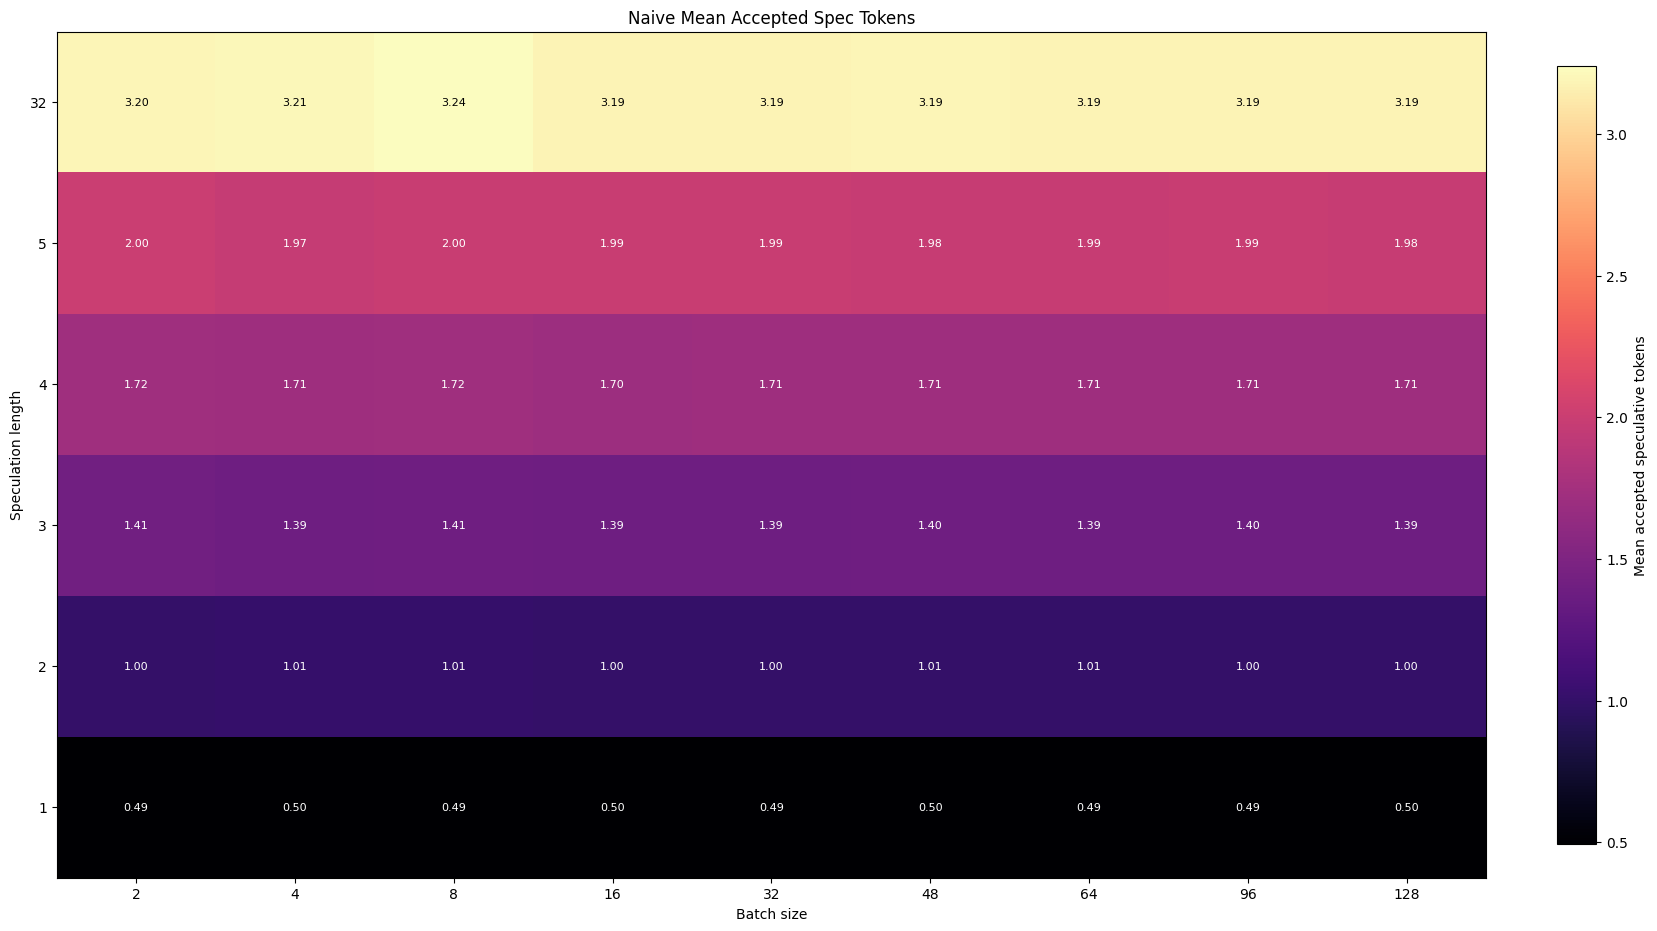

(bs        2    4    8    16   32   48   64   96   128
 spec_len                                             
 1         1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0  1.0
 2         2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0
 3         2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0
 4         2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0
 5         2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0
 32        2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0  2.0,
 bs             2         4         8         16        32        48   \
 spec_len                                                               
 1         0.494906  0.497828  0.493820  0.495249  0.494808  0.495788   
 2         1.003089  1.012434  1.012934  1.001746  1.004941  1.005513   
 3         1.410217  1.393454  1.405889  1.393483  1.391978  1.395824   
 4         1.724499  1.712552  1.723786  1.703339  1.714873  1.709316   
 5         1.999808  1.974169  1.995721  1.991041  1.991512  1.984245   
 32        3.198933  3.206590  3.242267  3.18753

In [6]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAIVE_DIR = Path('bench_csvs/naive')
PAT = re.compile(r'^naive-speclen_(?P<sl>\d+)-bs_(?P<bs>\d+)-n128-\d{8}-\d{6}-[0-9a-f]+\.decode_len_hist\.json$')


def cdf_p50_l_from_hist(hist: dict[int, int], spec_len: int, n: int) -> float:
    ls = np.arange(1, spec_len + 1, dtype=int)
    surv = np.array([
        sum(hist.get(int(k), 0) for k in range(int(l), spec_len + 1)) / n
        for l in ls
    ], dtype=float)
    cdf = 1.0 - surv
    idx = int(np.searchsorted(cdf, 0.5, side='left'))
    idx = min(max(idx, 0), len(ls) - 1)
    return float(ls[idx])


def mean_from_hist(hist: dict[int, int], n: int) -> float:
    if n <= 0:
        return np.nan
    return float(sum(k * v for k, v in hist.items()) / n)


rows = []
for p in sorted(NAIVE_DIR.glob('naive-speclen_*-bs_*-n128-*.decode_len_hist.json')):
    m = PAT.match(p.name)
    if not m:
        continue

    sl = int(m.group('sl'))
    bs = int(m.group('bs'))

    with open(p, 'r', encoding='utf-8') as f:
        payload = json.load(f)

    acc = payload.get('accepted_spec_tokens', {})
    hist_raw = acc.get('hist', {})
    hist = {int(k): int(v) for k, v in hist_raw.items() if int(v) > 0}
    n = int(acc.get('num_samples', sum(hist.values())))
    if n <= 0:
        n = sum(hist.values())
    if not hist or n <= 0:
        continue

    rows.append({
        'spec_len': sl,
        'bs': bs,
        'p50_l': cdf_p50_l_from_hist(hist, sl, n),
        'mean_accepted_spec_tokens': mean_from_hist(hist, n),
    })

hdf = pd.DataFrame(rows)
if hdf.empty:
    raise RuntimeError('No naive decode_len_hist.json files with accepted_spec_tokens found.')

spec_lens = sorted(hdf['spec_len'].unique())
batch_sizes = sorted(hdf['bs'].unique())

pivot_p50 = hdf.pivot(index='spec_len', columns='bs', values='p50_l').reindex(index=spec_lens, columns=batch_sizes)
pivot_mean = hdf.pivot(index='spec_len', columns='bs', values='mean_accepted_spec_tokens').reindex(index=spec_lens, columns=batch_sizes)

fig1, ax1 = plt.subplots(1, 1, figsize=(1.5 * len(batch_sizes) + 3, 1.2 * len(spec_lens) + 2), constrained_layout=True)
im1 = ax1.imshow(pivot_p50.values, origin='lower', cmap='magma', aspect='auto')
ax1.set_title('Naive CDF Median Threshold (p50 l)')
ax1.set_xlabel('Batch size')
ax1.set_ylabel('Speculation length')
ax1.set_xticks(range(len(batch_sizes)))
ax1.set_xticklabels(batch_sizes)
ax1.set_yticks(range(len(spec_lens)))
ax1.set_yticklabels(spec_lens)

for r in range(len(spec_lens)):
    for c in range(len(batch_sizes)):
        val = pivot_p50.values[r, c]
        if np.isfinite(val):
            rgba = im1.cmap(im1.norm(val))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'black' if luminance > 0.55 else 'white'
            ax1.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=8)

cbar1 = fig1.colorbar(im1, ax=ax1, shrink=0.92)
cbar1.set_label('l where F(l)=P(accepted<l) reaches 50%')
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(1.5 * len(batch_sizes) + 3, 1.2 * len(spec_lens) + 2), constrained_layout=True)
im2 = ax2.imshow(pivot_mean.values, origin='lower', cmap='magma', aspect='auto')
ax2.set_title('Naive Mean Accepted Spec Tokens')
ax2.set_xlabel('Batch size')
ax2.set_ylabel('Speculation length')
ax2.set_xticks(range(len(batch_sizes)))
ax2.set_xticklabels(batch_sizes)
ax2.set_yticks(range(len(spec_lens)))
ax2.set_yticklabels(spec_lens)

for r in range(len(spec_lens)):
    for c in range(len(batch_sizes)):
        val = pivot_mean.values[r, c]
        if np.isfinite(val):
            rgba = im2.cmap(im2.norm(val))
            luminance = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
            txt_color = 'black' if luminance > 0.55 else 'white'
            ax2.text(c, r, f'{val:.2f}', ha='center', va='center', color=txt_color, fontsize=8)

cbar2 = fig2.colorbar(im2, ax=ax2, shrink=0.92)
cbar2.set_label('Mean accepted speculative tokens')
plt.show()

pivot_p50, pivot_mean


# MEDUSA p50 Survival-CDF Heatmap Grid by Batch Size
For each MEDUSA run, compute `l` where `F(l)=P(accepted<l)` first reaches 0.5 (from `accepted_spec_tokens` histogram), then plot one heatmap per batch size with y=`c1`, x=`c2`.

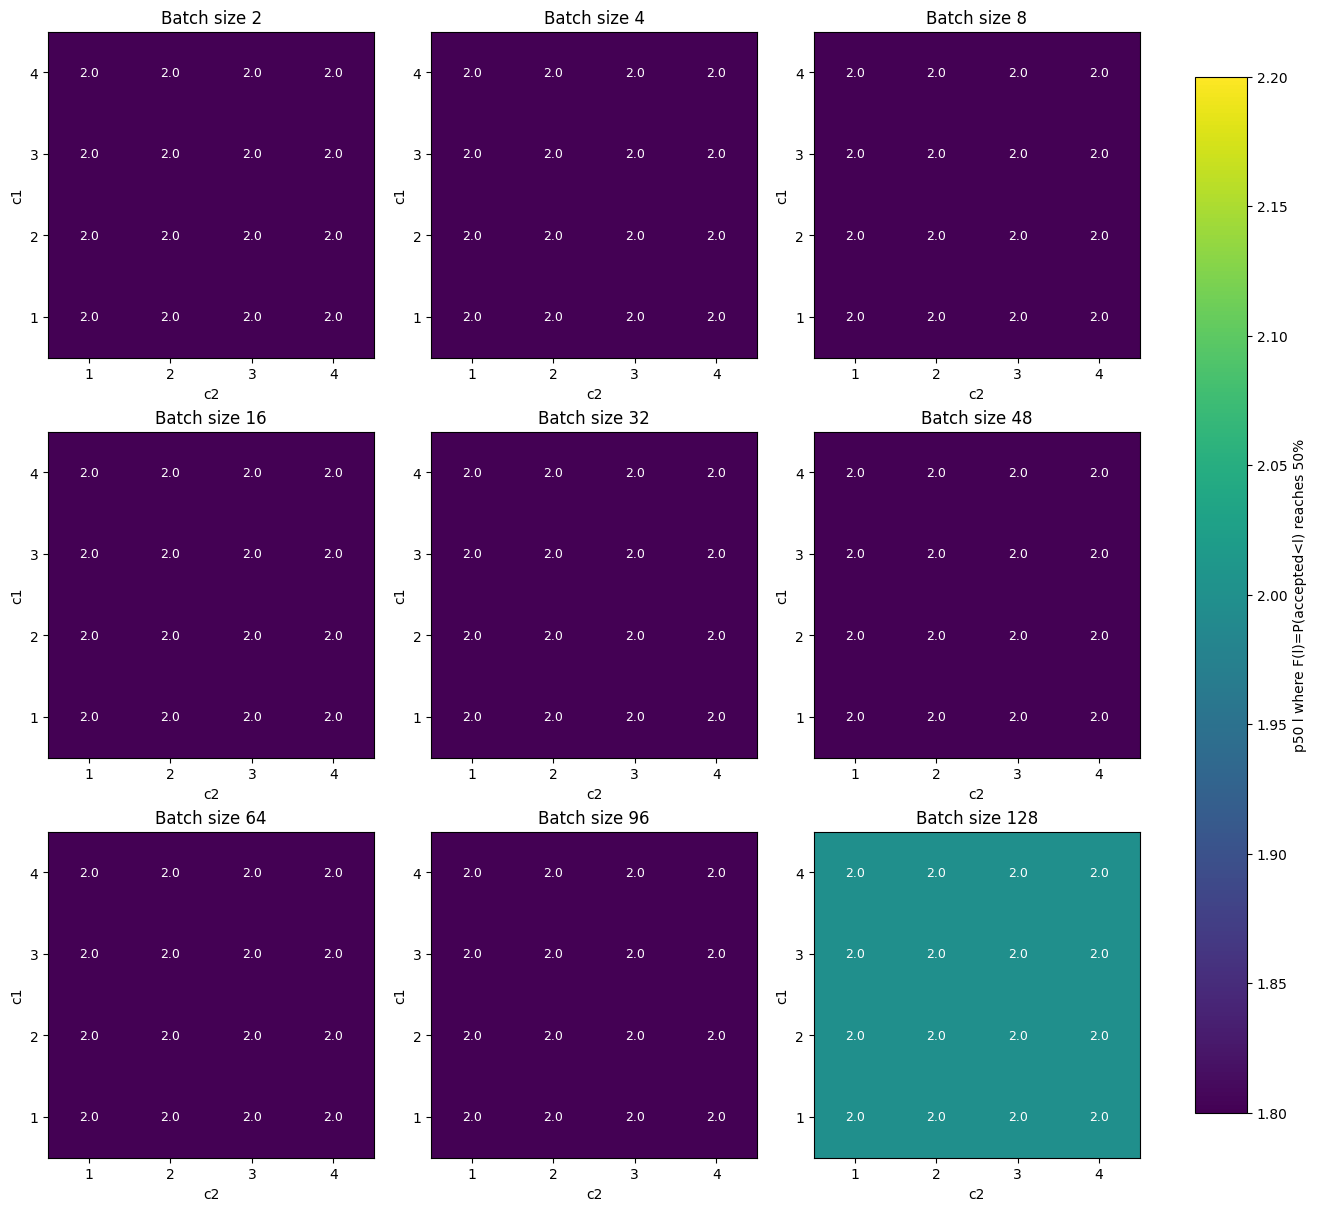

,bs,c1,c2,p50_l
0,2,1,1,2.0
1,2,1,2,2.0
2,2,1,3,2.0
3,2,1,4,2.0
4,2,2,1,2.0
...,...,...,...,...
139,128,3,4,2.0
140,128,4,1,2.0
141,128,4,2,2.0
142,128,4,3,2.0


In [7]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MEDUSA_DIR = Path('bench_csvs/medusa')
PAT = re.compile(
    r'^medusa_bs(?P<bs>\d+)_c1_(?P<c1>\d+)_c2_(?P<c2>\d+)_n\d+-\d{8}-\d{6}-[0-9a-f]+\.decode_len_hist\.json$'
)


def cdf_p50_l_from_hist(hist: dict[int, int], max_l: int, n: int) -> float:
    # S(l)=P(accepted>=l), F(l)=P(accepted<l)=1-S(l)
    ls = np.arange(1, max_l + 1, dtype=int)
    surv = np.array([
        sum(hist.get(int(k), 0) for k in range(int(l), max_l + 1)) / n
        for l in ls
    ], dtype=float)
    cdf = 1.0 - surv
    idx = int(np.searchsorted(cdf, 0.5, side='left'))
    idx = min(max(idx, 0), len(ls) - 1)
    return float(ls[idx])


rows = []
files = sorted(MEDUSA_DIR.glob('medusa_bs*_c1_*_c2_*_n*-*.decode_len_hist.json'))
for p in files:
    m = PAT.match(p.name)
    if not m:
        continue

    bs = int(m.group('bs'))
    c1 = int(m.group('c1'))
    c2 = int(m.group('c2'))

    with open(p, 'r', encoding='utf-8') as f:
        payload = json.load(f)

    acc = payload.get('accepted_spec_tokens', {})
    hist_raw = acc.get('hist', {})
    hist = {int(k): int(v) for k, v in hist_raw.items() if int(v) > 0}
    n = int(acc.get('num_samples', sum(hist.values())))
    if n <= 0:
        n = sum(hist.values())
    if not hist or n <= 0:
        continue

    max_l = max(hist.keys())
    rows.append({'bs': bs, 'c1': c1, 'c2': c2, 'p50_l': cdf_p50_l_from_hist(hist, max_l=max_l, n=n)})

medusa_p50_df = pd.DataFrame(rows)
if medusa_p50_df.empty:
    raise RuntimeError(
        f'No MEDUSA decode_len_hist.json files with accepted_spec_tokens found. '
        f'Checked {len(files)} files under {MEDUSA_DIR.resolve()}'
    )

medusa_p50_df = medusa_p50_df.groupby(['bs', 'c1', 'c2'], as_index=False)['p50_l'].mean()

batch_sizes = sorted(medusa_p50_df['bs'].unique())
c1_vals = sorted(medusa_p50_df['c1'].unique())
c2_vals = sorted(medusa_p50_df['c2'].unique())

n = len(batch_sizes)
ncols = min(3, n)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 4.0 * nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

vmin = medusa_p50_df['p50_l'].min()
vmax = medusa_p50_df['p50_l'].max()
last_im = None

for i, bs in enumerate(batch_sizes):
    ax = axes[i]
    piv = (
        medusa_p50_df[medusa_p50_df['bs'] == bs]
        .pivot(index='c1', columns='c2', values='p50_l')
        .reindex(index=c1_vals, columns=c2_vals)
    )

    im = ax.imshow(piv.values, origin='lower', cmap='viridis', aspect='equal', vmin=vmin, vmax=vmax)
    last_im = im

    ax.set_title(f'Batch size {bs}')
    ax.set_xlabel('c2')
    ax.set_ylabel('c1')
    ax.set_xticks(range(len(c2_vals)))
    ax.set_xticklabels(c2_vals)
    ax.set_yticks(range(len(c1_vals)))
    ax.set_yticklabels(c1_vals)

    for r in range(len(c1_vals)):
        for c in range(len(c2_vals)):
            val = piv.values[r, c]
            if np.isfinite(val):
                rgba = im.cmap(im.norm(val))
                lum = 0.2126 * rgba[0] + 0.7152 * rgba[1] + 0.0722 * rgba[2]
                txt_color = 'black' if lum > 0.55 else 'white'
                ax.text(c, r, f'{val:.1f}', ha='center', va='center', color=txt_color, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

if last_im is not None:
    cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.92)
    cbar.set_label('p50 l where F(l)=P(accepted<l) reaches 50%')

plt.show()

medusa_p50_df
